In [ ]:
!pip install wandb huggingface_hub -q

In [ ]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nitinkumarmalviya_25afi24 (nitinkumarmalviya_25afi24-delhi-technological-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os
from torch.utils.data import DataLoader
from huggingface_hub import HfApi, create_repo

HF_REPO = "nitin032/exp9-gans"

WANDB_PROJECT = "exp9-gans"
EPOCHS        = 5
BATCH_SIZE    = 128
LATENT_DIM    = 100
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LOSS_FNS   = ["bce", "lsgan", "wgan"]
OPTIMIZERS = ["adam", "sgd", "rmsprop"]
MODELS     = ["vanilla", "dcgan"]

print(DEVICE)

cuda


### Dataset

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.92MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 155kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.85MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.8MB/s]

train: 60000  test: 10000


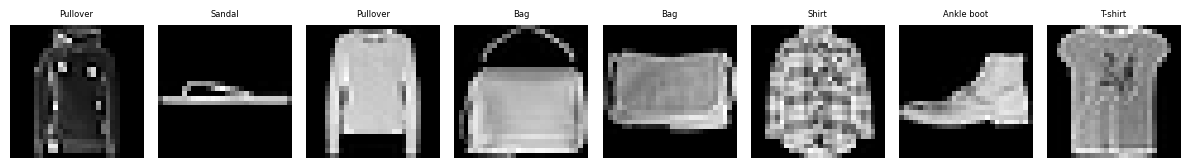

In [ ]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_data = torchvision.datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'train: {len(train_data)}  test: {len(test_data)}')

imgs, labels = next(iter(train_loader))
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    axes[i].imshow(imgs[i].squeeze(), cmap='gray')
    axes[i].set_title(class_names[labels[i]], fontsize=6)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Vanilla GAN - Generator and Discriminator

In [ ]:
class VanillaGenerator(nn.Module):
    def __init__(self, latent_dim):
        super(VanillaGenerator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


class VanillaDiscriminator(nn.Module):
    def __init__(self):
        super(VanillaDiscriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.net(x)

### DCGAN - Generator and Discriminator

In [ ]:
class DCGenerator(nn.Module):
    def __init__(self, latent_dim):
        super(DCGenerator, self).__init__()
        self.net = nn.Sequential(
            # latent -> 7x7x256
            nn.ConvTranspose2d(latent_dim, 256, 7, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # 7x7 -> 14x14
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # 14x14 -> 28x28
            nn.ConvTranspose2d(128, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        z = z.view(z.size(0), z.size(1), 1, 1)
        return self.net(z)


class DCDiscriminator(nn.Module):
    def __init__(self):
        super(DCDiscriminator, self).__init__()
        self.net = nn.Sequential(
            # 28x28 -> 14x14
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 14x14 -> 7x7
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # 7x7 -> 1x1
            nn.Conv2d(128, 1, 7, 1, 0, bias=False)
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

### Loss Functions - BCE, LSGAN, WGAN

In [ ]:
bce = nn.BCEWithLogitsLoss()
mse = nn.MSELoss()

def disc_loss(real_out, fake_out, loss_type):
    if loss_type == 'bce':
        real_loss = bce(real_out, torch.ones_like(real_out))
        fake_loss = bce(fake_out, torch.zeros_like(fake_out))
        return (real_loss + fake_loss) / 2
    elif loss_type == 'lsgan':
        real_loss = mse(real_out, torch.ones_like(real_out))
        fake_loss = mse(fake_out, torch.zeros_like(fake_out))
        return (real_loss + fake_loss) / 2
    elif loss_type == 'wgan':
        return -(real_out.mean() - fake_out.mean())

def gen_loss(fake_out, loss_type):
    if loss_type == 'bce':
        return bce(fake_out, torch.ones_like(fake_out))
    elif loss_type == 'lsgan':
        return mse(fake_out, torch.ones_like(fake_out))
    elif loss_type == 'wgan':
        return -fake_out.mean()

### Optimizer Factory

In [ ]:
def get_optimizer(model, name):
    if name == 'adam':
        return optim.Adam(model.parameters(), lr=2e-4, betas=(0.5, 0.999))
    elif name == 'sgd':
        return optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)
    else:
        return optim.RMSprop(model.parameters(), lr=5e-5)

### Training Loop

In [ ]:
def train_epoch(G, D, loader, opt_g, opt_d, loss_type):
    G.train(); D.train()
    g_running = 0
    d_running = 0

    for real, _ in loader:
        real = real.to(DEVICE)
        bs   = real.size(0)

        # train discriminator
        z         = torch.randn(bs, LATENT_DIM).to(DEVICE)
        fake      = G(z).detach()
        real_out  = D(real)
        fake_out  = D(fake)
        d_loss    = disc_loss(real_out, fake_out, loss_type)
        opt_d.zero_grad()
        d_loss.backward()
        opt_d.step()

        # weight clipping for wgan
        if loss_type == 'wgan':
            for p in D.parameters():
                p.data.clamp_(-0.01, 0.01)

        # train generator
        z        = torch.randn(bs, LATENT_DIM).to(DEVICE)
        fake     = G(z)
        fake_out = D(fake)
        g_loss   = gen_loss(fake_out, loss_type)
        opt_g.zero_grad()
        g_loss.backward()
        opt_g.step()

        g_running += g_loss.item()
        d_running += d_loss.item()

    n = len(loader)
    return g_running / n, d_running / n

### Visualization

In [ ]:
def show_generated(G, epoch, tag, n=16):
    G.eval()
    with torch.no_grad():
        z    = torch.randn(n, LATENT_DIM).to(DEVICE)
        imgs = G(z).cpu()
    imgs = (imgs + 1) / 2
    fig, axes = plt.subplots(2, 8, figsize=(12, 3))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(imgs[i].squeeze(), cmap='gray')
        ax.axis('off')
    plt.suptitle(f'epoch {epoch} - {tag}', fontsize=9)
    plt.tight_layout()
    plt.show()
    return fig

### Main Experiment Runner

In [ ]:
results       = {}
saved_generators = {}

def run_experiment(arch, loss_type, opt_name):
    name = f'{arch}_{loss_type}_{opt_name}'
    print(f'\nstarting: {name}')

    wandb.init(project=WANDB_PROJECT, name=name, config={
        'arch': arch, 'loss': loss_type, 'optimizer': opt_name, 'epochs': EPOCHS
    })

    if arch == 'vanilla':
        G = VanillaGenerator(LATENT_DIM).to(DEVICE)
        D = VanillaDiscriminator().to(DEVICE)
    else:
        G = DCGenerator(LATENT_DIM).to(DEVICE)
        D = DCDiscriminator().to(DEVICE)

    opt_g = get_optimizer(G, opt_name)
    opt_d = get_optimizer(D, opt_name)

    g_losses = []
    d_losses = []

    for epoch in range(1, EPOCHS + 1):
        g_loss, d_loss = train_epoch(G, D, train_loader, opt_g, opt_d, loss_type)
        g_losses.append(g_loss)
        d_losses.append(d_loss)
        wandb.log({'epoch': epoch, 'g_loss': g_loss, 'd_loss': d_loss})
        print(f'  epoch {epoch}/{EPOCHS}  g_loss={g_loss:.4f}  d_loss={d_loss:.4f}')

        if epoch % 5 == 0 or epoch == EPOCHS:
            fig = show_generated(G, epoch, name)
            wandb.log({f'generated_ep{epoch}': wandb.Image(fig)})
            plt.close(fig)

    # loss curves
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(g_losses, label='generator')
    ax.plot(d_losses, label='discriminator')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.set_title(name)
    ax.legend()
    plt.tight_layout()
    plt.show()
    wandb.log({'loss_curve': wandb.Image(fig)})
    plt.close(fig)

    torch.save(G.state_dict(), f'{name}_G.pt')
    torch.save(D.state_dict(), f'{name}_D.pt')
    saved_generators[name] = G
    results[name] = {'g_loss': g_losses[-1], 'd_loss': d_losses[-1]}

    wandb.finish()
    return G, D

### Quick Test - run this first


starting: vanilla_bce_adam


  epoch 1/5  g_loss=1.1553  d_loss=0.4892
  epoch 2/5  g_loss=1.7530  d_loss=0.4536
  epoch 3/5  g_loss=1.9552  d_loss=0.4642
  epoch 4/5  g_loss=1.4657  d_loss=0.5405
  epoch 5/5  g_loss=1.4033  d_loss=0.5520


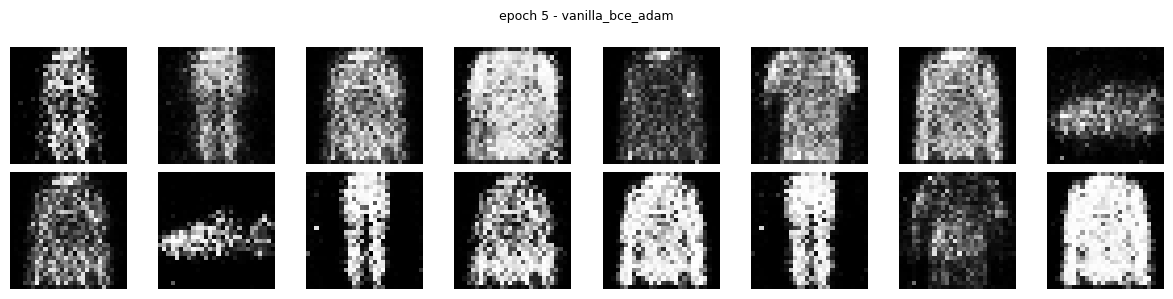

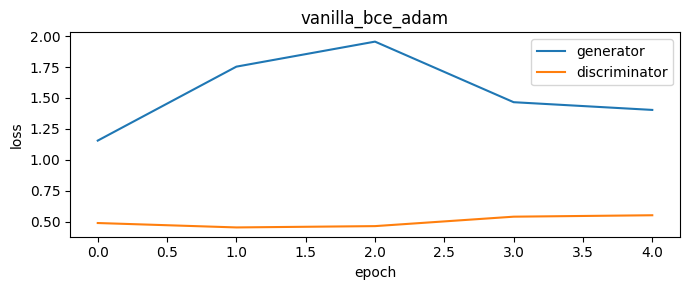

d_loss,▄▁▂▇█
epoch,▁▃▅▆█
g_loss,▁▆█▄▃
d_loss,0.55197
epoch,5
g_loss,1.40329



starting: dcgan_bce_adam


  epoch 1/5  g_loss=2.6486  d_loss=0.2757
  epoch 2/5  g_loss=1.3785  d_loss=0.4190
  epoch 3/5  g_loss=1.1676  d_loss=0.4944
  epoch 4/5  g_loss=1.0961  d_loss=0.5217
  epoch 5/5  g_loss=1.0924  d_loss=0.5308


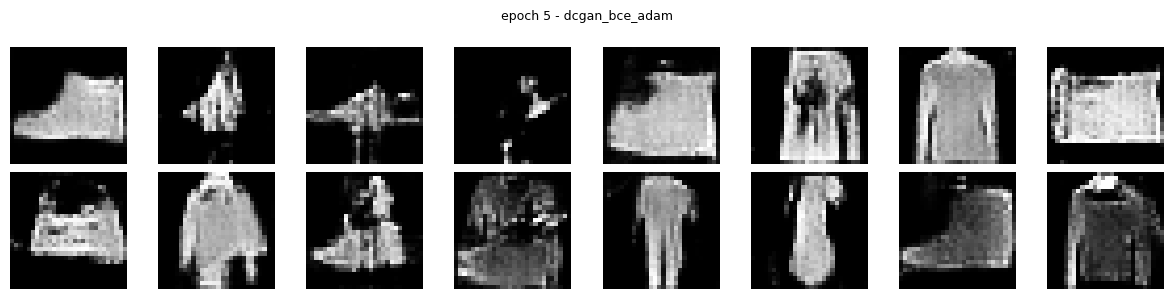

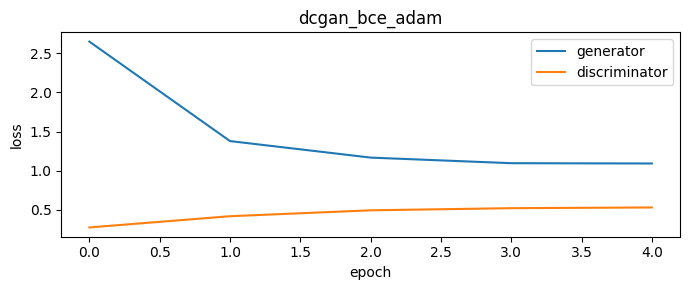

d_loss,▁▅▇██
epoch,▁▃▅▆█
g_loss,█▂▁▁▁
d_loss,0.53079
epoch,5
g_loss,1.0924


(DCGenerator(
   (net): Sequential(
     (0): ConvTranspose2d(100, 256, kernel_size=(7, 7), stride=(1, 1), bias=False)
     (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (2): ReLU(inplace=True)
     (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (5): ReLU(inplace=True)
     (6): ConvTranspose2d(128, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (7): Tanh()
   )
 ),
 DCDiscriminator(
   (net): Sequential(
     (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (1): LeakyReLU(negative_slope=0.2, inplace=True)
     (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (4): LeakyReLU(negative_slope=0.2, inplace=True)
    

In [ ]:
run_experiment('vanilla', 'bce', 'adam')
run_experiment('dcgan',   'bce', 'adam')

### Full Grid - all combinations


starting: vanilla_bce_adam


  epoch 1/5  g_loss=1.2823  d_loss=0.4720
  epoch 2/5  g_loss=1.8223  d_loss=0.4799
  epoch 3/5  g_loss=1.8014  d_loss=0.4903
  epoch 4/5  g_loss=1.5397  d_loss=0.5143
  epoch 5/5  g_loss=1.3022  d_loss=0.5549


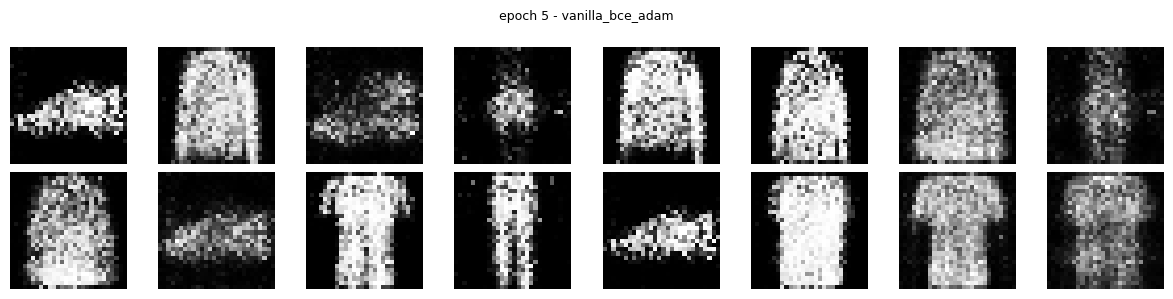

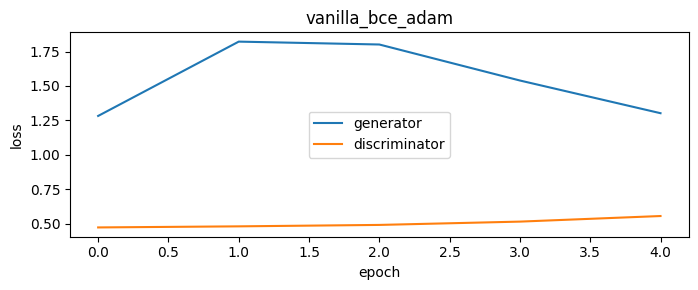

d_loss,▁▂▃▅█
epoch,▁▃▅▆█
g_loss,▁██▄▁
d_loss,0.55492
epoch,5
g_loss,1.30215



starting: vanilla_bce_sgd


  epoch 1/5  g_loss=0.7709  d_loss=0.3820
  epoch 2/5  g_loss=1.5374  d_loss=0.2911
  epoch 3/5  g_loss=2.4659  d_loss=0.1562
  epoch 4/5  g_loss=2.8001  d_loss=0.1488
  epoch 5/5  g_loss=3.2331  d_loss=0.1379


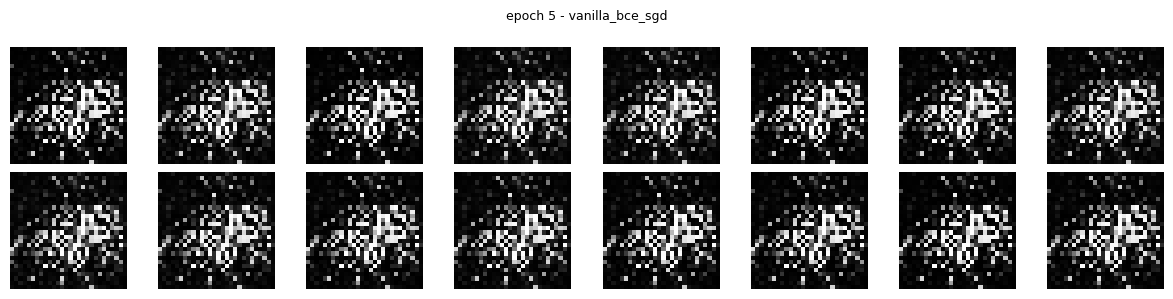

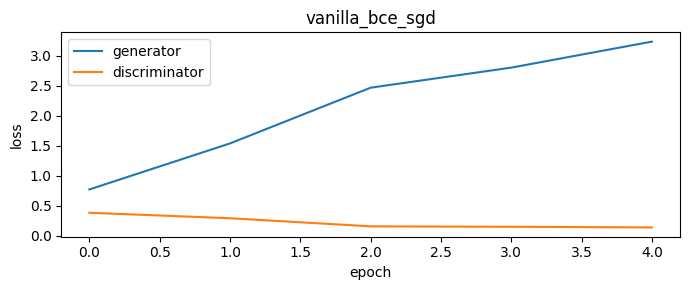

d_loss,█▅▂▁▁
epoch,▁▃▅▆█
g_loss,▁▃▆▇█
d_loss,0.13795
epoch,5
g_loss,3.2331



starting: vanilla_bce_rmsprop


  epoch 1/5  g_loss=0.8476  d_loss=0.4749
  epoch 2/5  g_loss=1.3950  d_loss=0.3661
  epoch 3/5  g_loss=2.0267  d_loss=0.2917
  epoch 4/5  g_loss=2.5151  d_loss=0.2506
  epoch 5/5  g_loss=2.7334  d_loss=0.2455


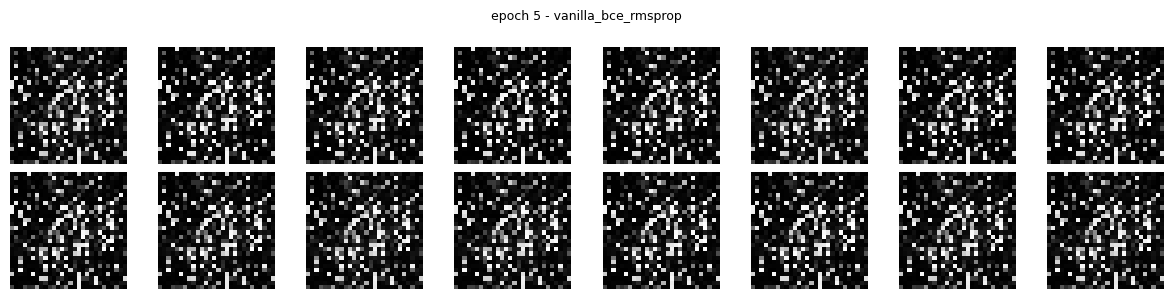

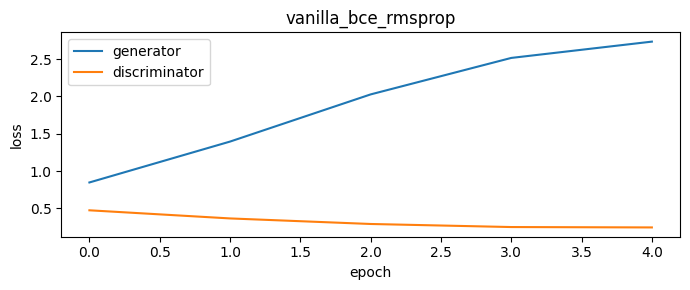

d_loss,█▅▂▁▁
epoch,▁▃▅▆█
g_loss,▁▃▅▇█
d_loss,0.24552
epoch,5
g_loss,2.73335



starting: vanilla_lsgan_adam


  epoch 1/5  g_loss=0.9702  d_loss=0.0789
  epoch 2/5  g_loss=0.8298  d_loss=0.1146
  epoch 3/5  g_loss=0.7272  d_loss=0.1399
  epoch 4/5  g_loss=0.6407  d_loss=0.1535
  epoch 5/5  g_loss=0.5508  d_loss=0.1703


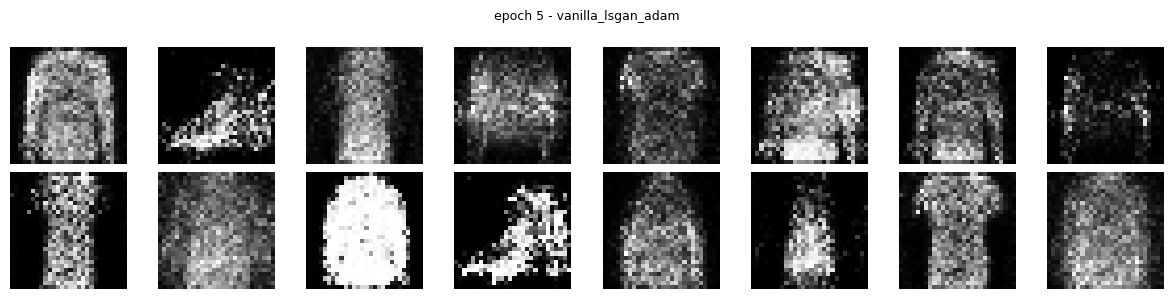

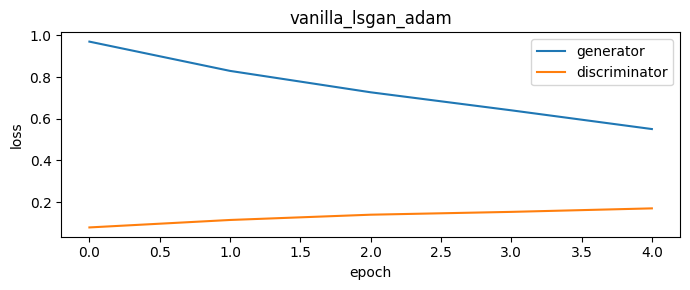

d_loss,▁▄▆▇█
epoch,▁▃▅▆█
g_loss,█▆▄▃▁
d_loss,0.17029
epoch,5
g_loss,0.55081



starting: vanilla_lsgan_sgd


  epoch 1/5  g_loss=0.7249  d_loss=0.0338
  epoch 2/5  g_loss=1.0108  d_loss=0.0355
  epoch 3/5  g_loss=0.9849  d_loss=0.0280
  epoch 4/5  g_loss=0.9711  d_loss=0.0267
  epoch 5/5  g_loss=0.9763  d_loss=0.0299


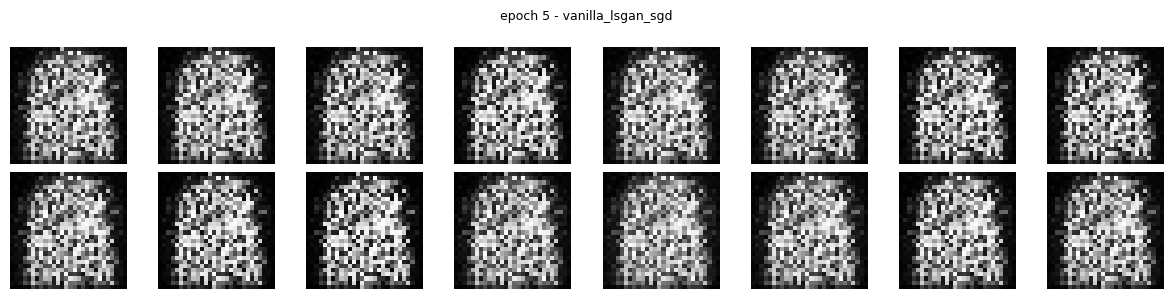

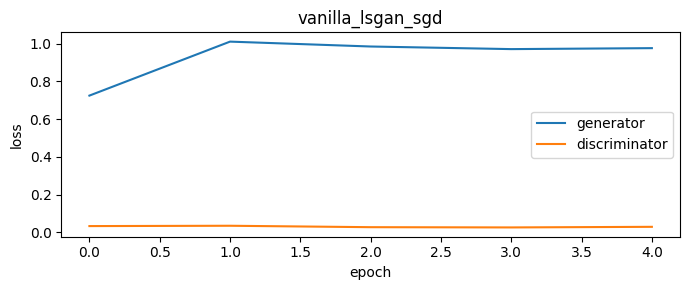

d_loss,▇█▂▁▄
epoch,▁▃▅▆█
g_loss,▁█▇▇▇
d_loss,0.02987
epoch,5
g_loss,0.97627



starting: vanilla_lsgan_rmsprop


  epoch 1/5  g_loss=0.8934  d_loss=0.0665
  epoch 2/5  g_loss=0.9647  d_loss=0.0779
  epoch 3/5  g_loss=0.9189  d_loss=0.0853
  epoch 4/5  g_loss=0.9461  d_loss=0.0860
  epoch 5/5  g_loss=0.9384  d_loss=0.0835


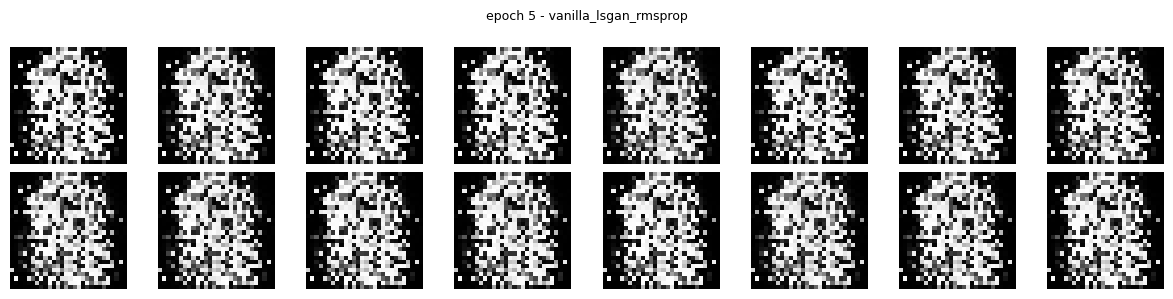

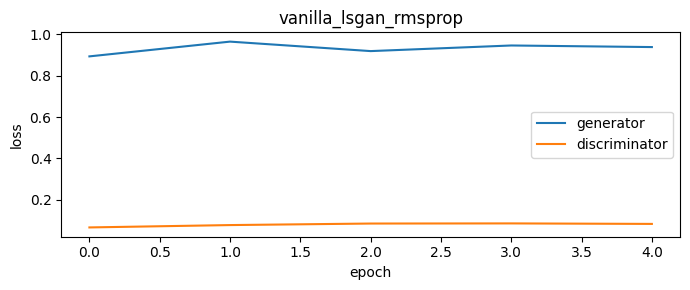

d_loss,▁▅██▇
epoch,▁▃▅▆█
g_loss,▁█▄▆▅
d_loss,0.08354
epoch,5
g_loss,0.93839



starting: vanilla_wgan_adam


  epoch 1/5  g_loss=-0.3876  d_loss=-0.3091
  epoch 2/5  g_loss=-0.3807  d_loss=-0.3526
  epoch 3/5  g_loss=-0.5717  d_loss=-0.5935
  epoch 4/5  g_loss=-0.7570  d_loss=-0.3535
  epoch 5/5  g_loss=-0.6587  d_loss=-0.2062


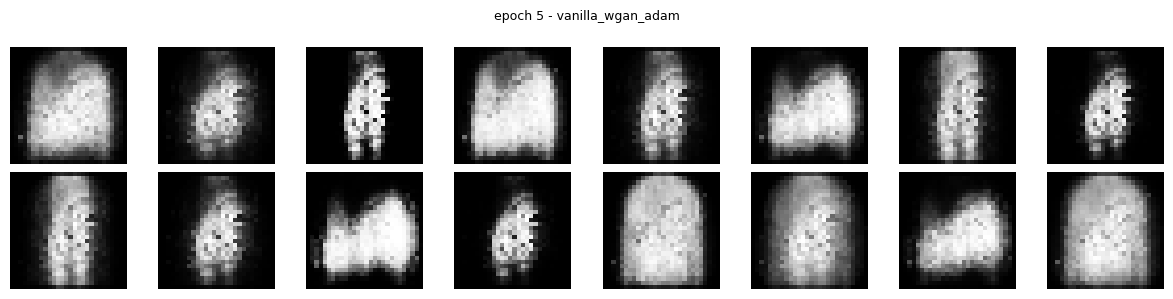

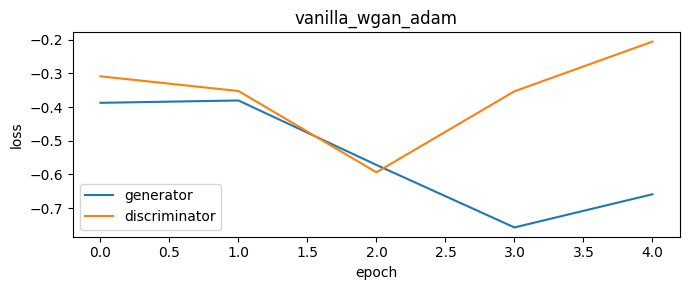

d_loss,▆▅▁▅█
epoch,▁▃▅▆█
g_loss,██▄▁▃
d_loss,-0.20619
epoch,5
g_loss,-0.65871



starting: vanilla_wgan_sgd


  epoch 1/5  g_loss=-0.1560  d_loss=-1.8927
  epoch 2/5  g_loss=2.1251  d_loss=-0.6638
  epoch 3/5  g_loss=2.6103  d_loss=-0.8017
  epoch 4/5  g_loss=-0.6174  d_loss=-2.6157
  epoch 5/5  g_loss=3.0737  d_loss=-0.8656


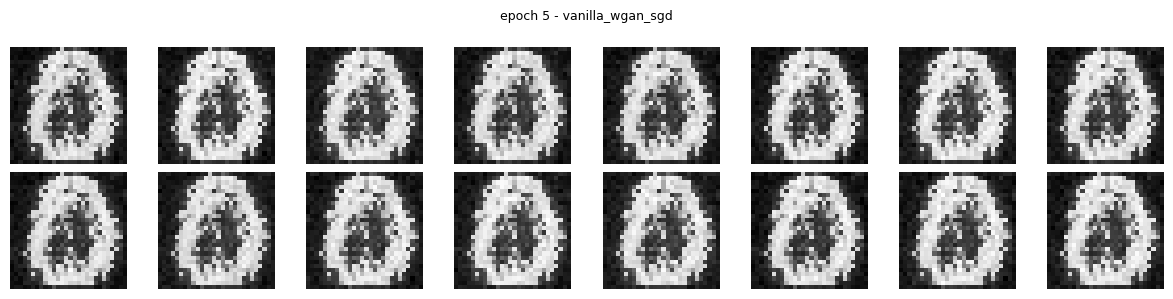

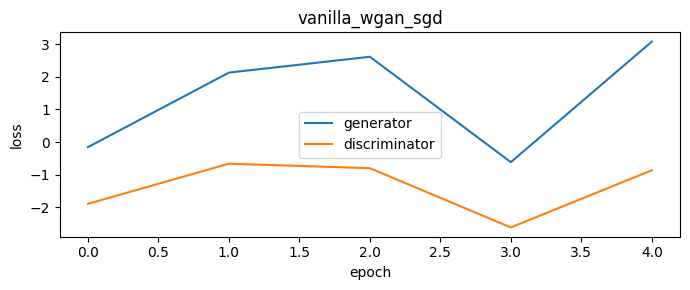

d_loss,▄██▁▇
epoch,▁▃▅▆█
g_loss,▂▆▇▁█
d_loss,-0.86561
epoch,5
g_loss,3.07371



starting: vanilla_wgan_rmsprop


  epoch 1/5  g_loss=-0.0897  d_loss=-0.1613
  epoch 2/5  g_loss=-0.2377  d_loss=-0.2385
  epoch 3/5  g_loss=-0.5396  d_loss=-0.3806
  epoch 4/5  g_loss=-0.2351  d_loss=-0.4714
  epoch 5/5  g_loss=-0.5037  d_loss=-0.5077


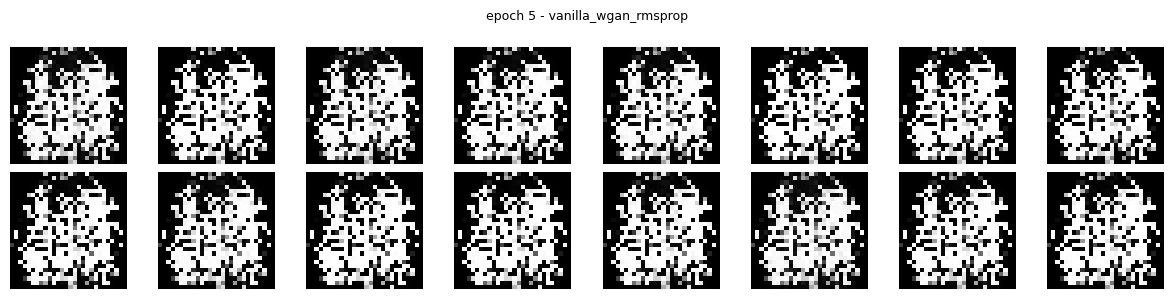

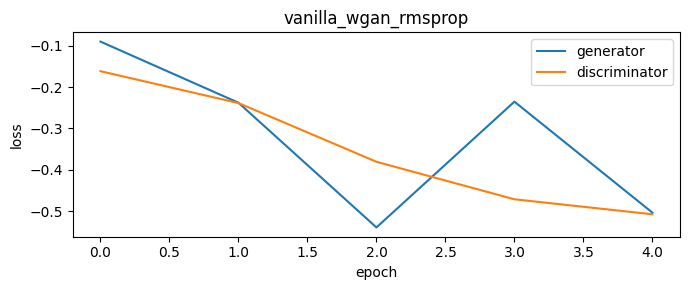

d_loss,█▆▄▂▁
epoch,▁▃▅▆█
g_loss,█▆▁▆▂
d_loss,-0.50771
epoch,5
g_loss,-0.50372



starting: dcgan_bce_adam


  epoch 1/5  g_loss=2.0254  d_loss=0.3075
  epoch 2/5  g_loss=1.4674  d_loss=0.3778
  epoch 3/5  g_loss=1.3123  d_loss=0.4491
  epoch 4/5  g_loss=1.4961  d_loss=0.4318
  epoch 5/5  g_loss=1.3126  d_loss=0.4667


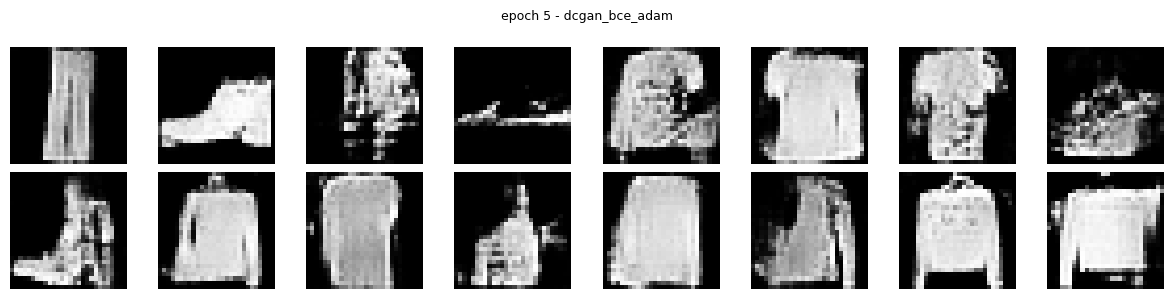

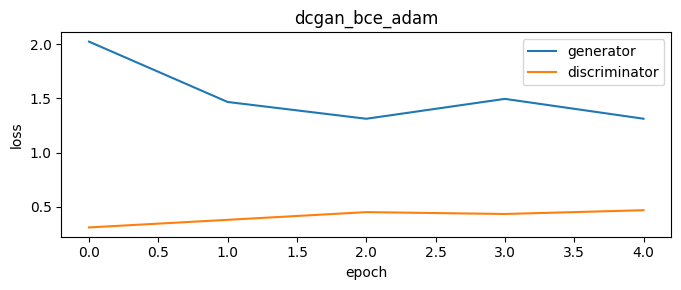

d_loss,▁▄▇▆█
epoch,▁▃▅▆█
g_loss,█▃▁▃▁
d_loss,0.46674
epoch,5
g_loss,1.3126



starting: dcgan_bce_sgd


  epoch 1/5  g_loss=6.2961  d_loss=0.0174
  epoch 2/5  g_loss=7.2496  d_loss=0.0033
  epoch 3/5  g_loss=6.7576  d_loss=0.0041
  epoch 4/5  g_loss=7.7527  d_loss=0.0010
  epoch 5/5  g_loss=8.6646  d_loss=0.0004


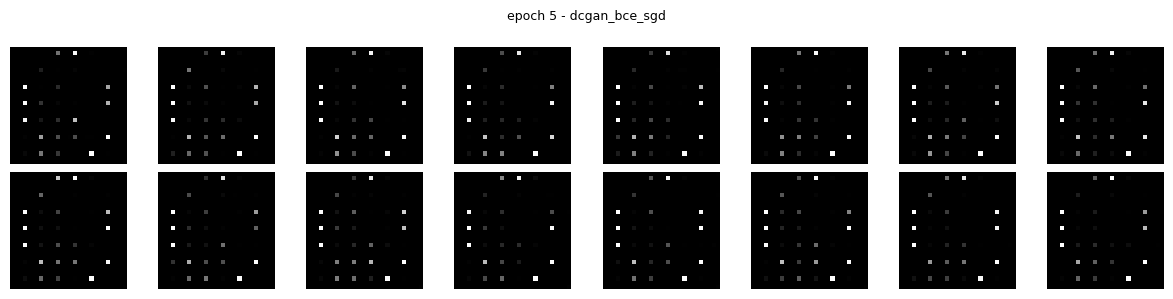

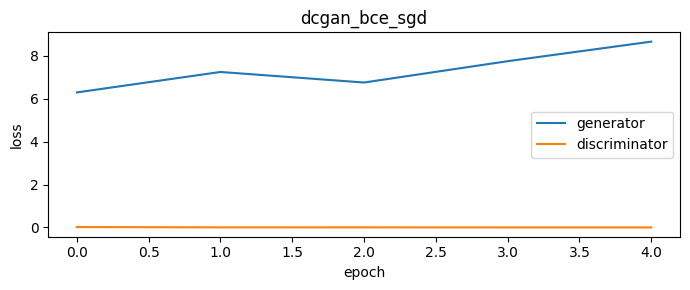

d_loss,█▂▃▁▁
epoch,▁▃▅▆█
g_loss,▁▄▂▅█
d_loss,0.00042
epoch,5
g_loss,8.66457



starting: dcgan_bce_rmsprop


  epoch 1/5  g_loss=1.3516  d_loss=0.3788
  epoch 2/5  g_loss=1.6822  d_loss=0.2633
  epoch 3/5  g_loss=1.6906  d_loss=0.2753
  epoch 4/5  g_loss=1.5185  d_loss=0.3291
  epoch 5/5  g_loss=1.3767  d_loss=0.3845


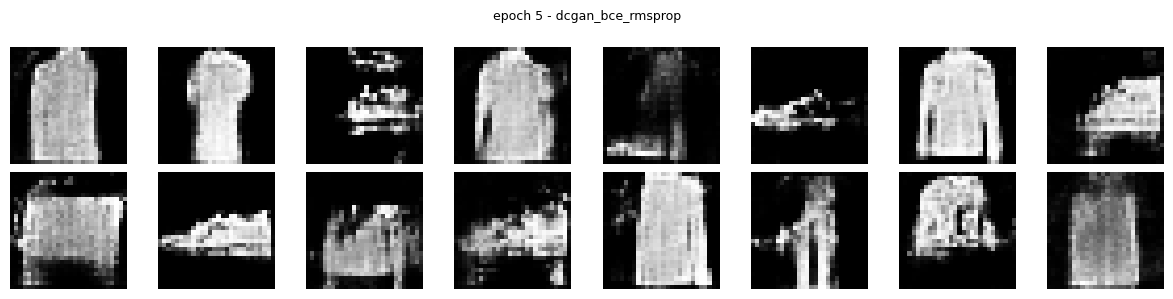

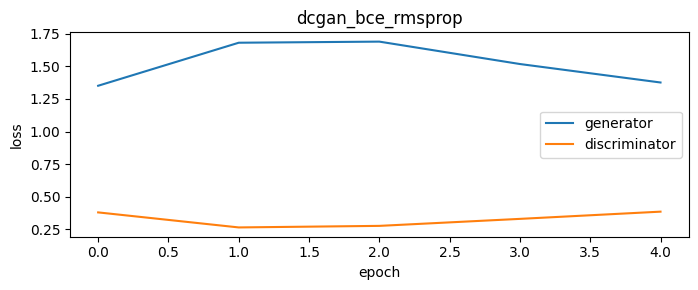

d_loss,█▁▂▅█
epoch,▁▃▅▆█
g_loss,▁██▄▂
d_loss,0.38455
epoch,5
g_loss,1.37669



starting: dcgan_lsgan_adam


  epoch 1/5  g_loss=0.7423  d_loss=0.1400
  epoch 2/5  g_loss=0.6470  d_loss=0.1198
  epoch 3/5  g_loss=0.5420  d_loss=0.1495
  epoch 4/5  g_loss=0.4943  d_loss=0.1712
  epoch 5/5  g_loss=0.4565  d_loss=0.1859


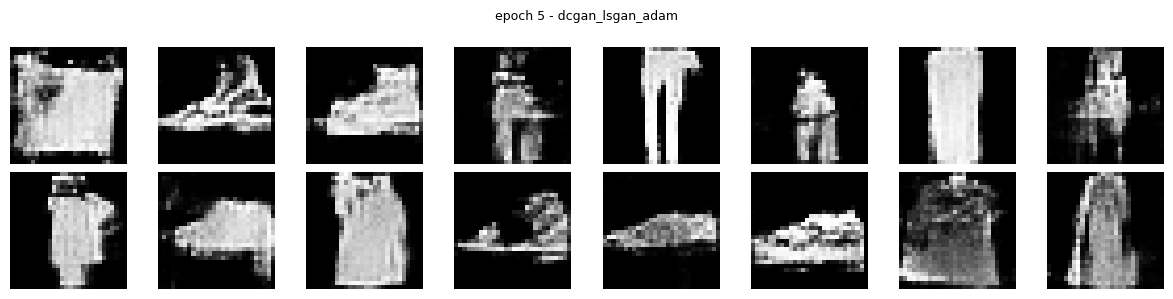

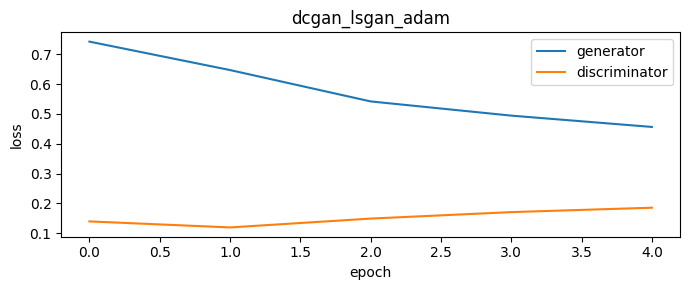

d_loss,▃▁▄▆█
epoch,▁▃▅▆█
g_loss,█▆▃▂▁
d_loss,0.18593
epoch,5
g_loss,0.45647



starting: dcgan_lsgan_sgd


  epoch 1/5  g_loss=1.1047  d_loss=0.0474
  epoch 2/5  g_loss=1.0107  d_loss=0.0050
  epoch 3/5  g_loss=1.0135  d_loss=0.0055
  epoch 4/5  g_loss=1.0050  d_loss=0.0031
  epoch 5/5  g_loss=1.0273  d_loss=0.0116


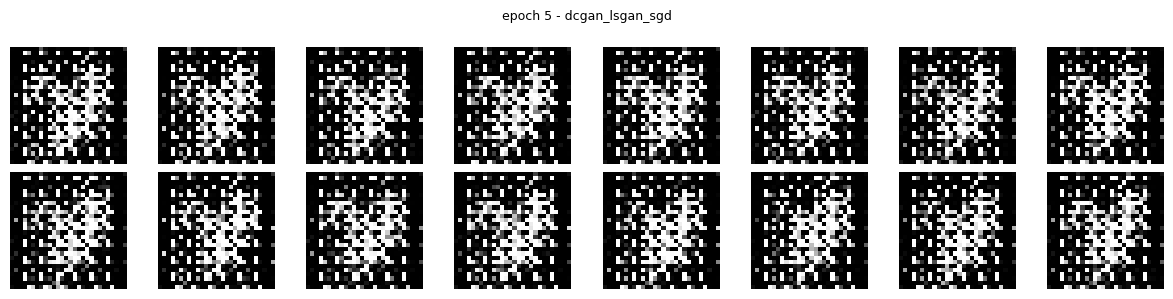

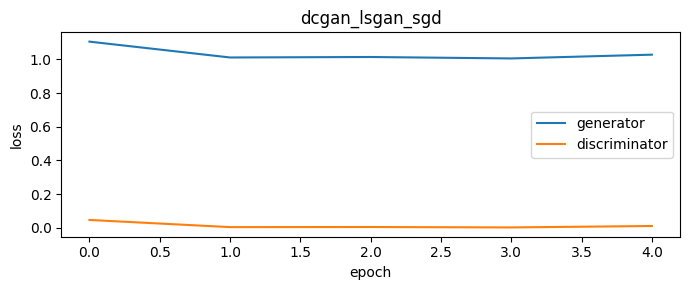

d_loss,█▁▁▁▂
epoch,▁▃▅▆█
g_loss,█▁▂▁▃
d_loss,0.01161
epoch,5
g_loss,1.02734



starting: dcgan_lsgan_rmsprop


  epoch 1/5  g_loss=1.0402  d_loss=0.0395
  epoch 2/5  g_loss=1.0163  d_loss=0.0176
  epoch 3/5  g_loss=1.0210  d_loss=0.0155
  epoch 4/5  g_loss=1.0242  d_loss=0.0157
  epoch 5/5  g_loss=1.0253  d_loss=0.0148


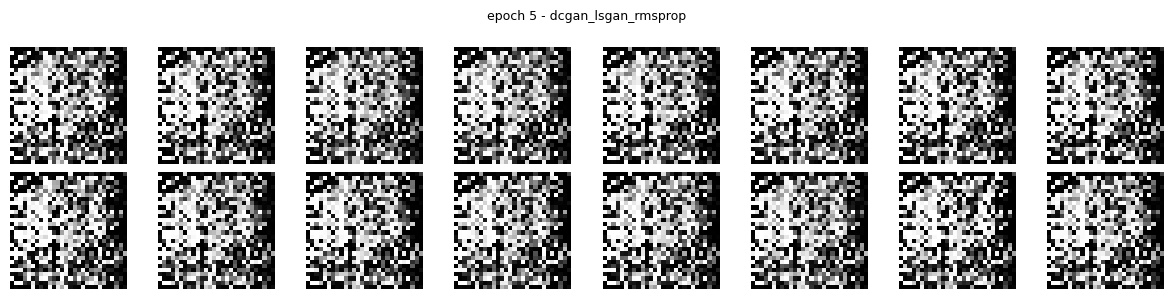

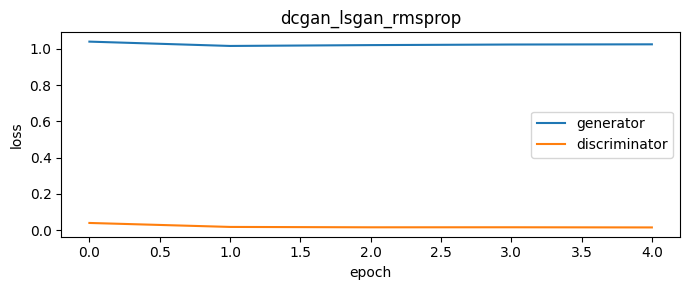

d_loss,█▂▁▁▁
epoch,▁▃▅▆█
g_loss,█▁▂▃▄
d_loss,0.01482
epoch,5
g_loss,1.02531



starting: dcgan_wgan_adam


  epoch 1/5  g_loss=-0.0021  d_loss=-0.0003
  epoch 2/5  g_loss=-0.0018  d_loss=-0.0042
  epoch 3/5  g_loss=-0.0046  d_loss=-0.0067
  epoch 4/5  g_loss=-0.0084  d_loss=-0.0064
  epoch 5/5  g_loss=-0.0103  d_loss=-0.0042


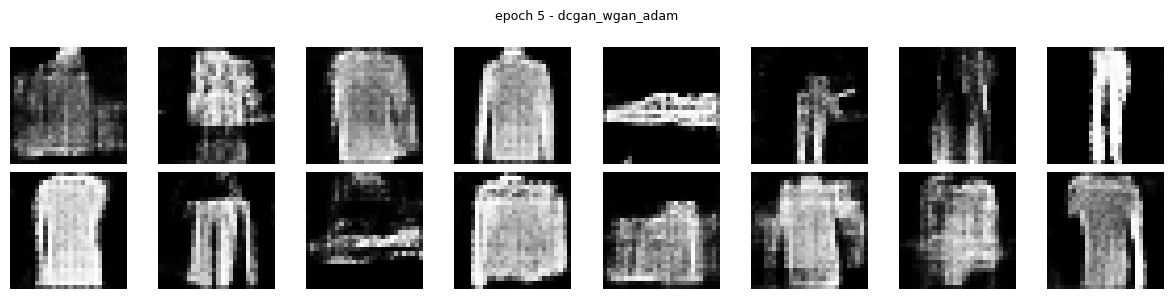

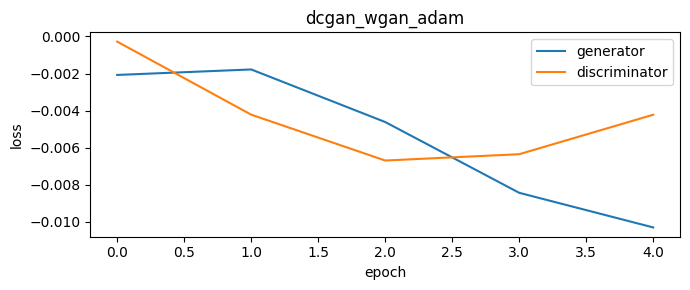

d_loss,█▄▁▁▄
epoch,▁▃▅▆█
g_loss,██▆▃▁
d_loss,-0.00423
epoch,5
g_loss,-0.01031



starting: dcgan_wgan_sgd


  epoch 1/5  g_loss=0.0260  d_loss=-0.1367
  epoch 2/5  g_loss=0.4179  d_loss=-0.6996
  epoch 3/5  g_loss=0.4618  d_loss=-0.8077
  epoch 4/5  g_loss=0.4348  d_loss=-0.5865
  epoch 5/5  g_loss=0.3776  d_loss=-0.5609


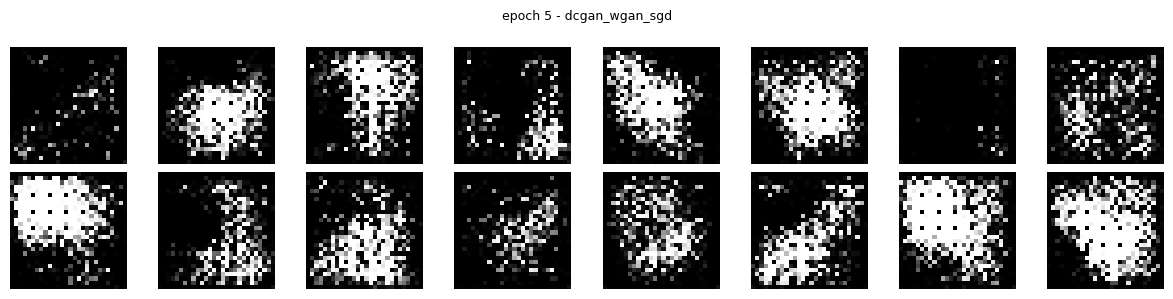

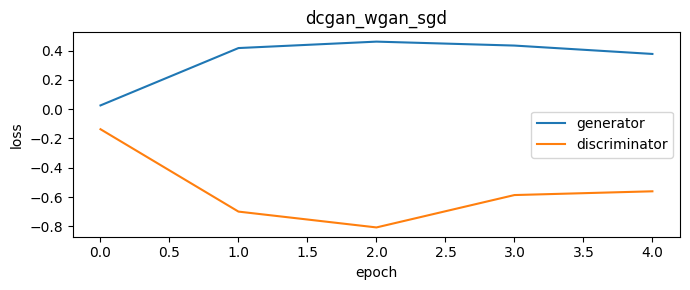

d_loss,█▂▁▃▄
epoch,▁▃▅▆█
g_loss,▁▇██▇
d_loss,-0.56087
epoch,5
g_loss,0.37759



starting: dcgan_wgan_rmsprop


  epoch 1/5  g_loss=0.0018  d_loss=-0.0204
  epoch 2/5  g_loss=0.0137  d_loss=-0.0121
  epoch 3/5  g_loss=0.0130  d_loss=-0.0270
  epoch 4/5  g_loss=0.0159  d_loss=-0.0244
  epoch 5/5  g_loss=0.0176  d_loss=-0.0192


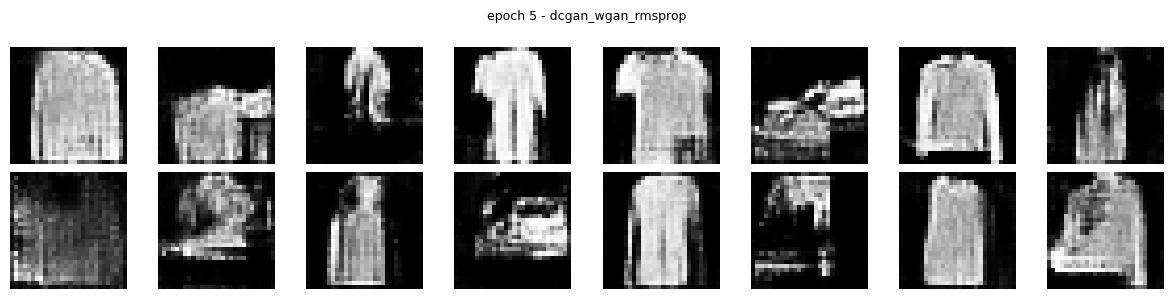

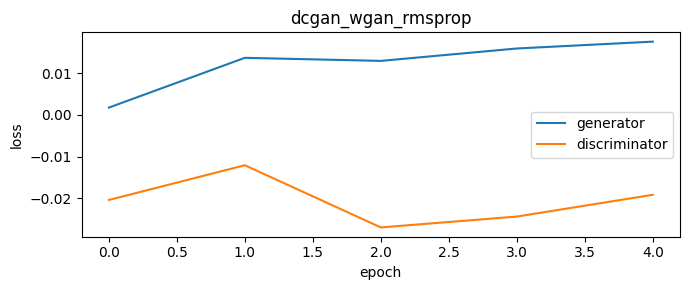

d_loss,▄█▁▂▅
epoch,▁▃▅▆█
g_loss,▁▆▆▇█
d_loss,-0.01918
epoch,5
g_loss,0.0176


In [ ]:
for arch in MODELS:
    for lf in LOSS_FNS:
        for opt in OPTIMIZERS:
            run_experiment(arch, lf, opt)

### Results Summary

In [ ]:
print(f'{"config":<35} {"g_loss":>10} {"d_loss":>10}')
print('-' * 57)
for k, v in sorted(results.items(), key=lambda x: x[1]['g_loss']):
    print(f'{k:<35} {v["g_loss"]:>10.4f} {v["d_loss"]:>10.4f}')

config                                  g_loss     d_loss
---------------------------------------------------------
vanilla_wgan_adam                      -0.6587    -0.2062
vanilla_wgan_rmsprop                   -0.5037    -0.5077
dcgan_wgan_adam                        -0.0103    -0.0042
dcgan_wgan_rmsprop                      0.0176    -0.0192
dcgan_wgan_sgd                          0.3776    -0.5609
dcgan_lsgan_adam                        0.4565     0.1859
vanilla_lsgan_adam                      0.5508     0.1703
vanilla_lsgan_rmsprop                   0.9384     0.0835
vanilla_lsgan_sgd                       0.9763     0.0299
dcgan_lsgan_rmsprop                     1.0253     0.0148
dcgan_lsgan_sgd                         1.0273     0.0116
vanilla_bce_adam                        1.3022     0.5549
dcgan_bce_adam                          1.3126     0.4667
dcgan_bce_rmsprop                       1.3767     0.3845
vanilla_bce_rmsprop                     2.7334     0.2455
vanilla_wgan_s

### Upload to HuggingFace

In [20]:
from huggingface_hub import login
login()

In [ ]:
create_repo(HF_REPO, exist_ok=True)
api = HfApi()

for name in saved_generators.keys():
    for suffix in ['_G.pt', '_D.pt']:
        fname = f'{name}{suffix}'
        if os.path.exists(fname):
            api.upload_file(
                path_or_fileobj=fname,
                path_in_repo=f'models/{fname}',
                repo_id=HF_REPO
            )
            print(f'uploaded: {fname}')

print(f'https://huggingface.co/{HF_REPO}')

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  vanilla_bce_adam_G.pt       :   9%|9         |  555kB / 5.95MB            

uploaded: vanilla_bce_adam_G.pt


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

...

uploaded: dcgan_wgan_rmsprop_G.pt


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  dcgan_wgan_rmsprop_D.pt     : 100%|##########|  559kB /  559kB            

uploaded: dcgan_wgan_rmsprop_D.pt
https://huggingface.co/nitin032/exp9-gans


In [ ]:
username = wandb.api.viewer()['entity']
print(f'W&B : https://wandb.ai/{username}/{WANDB_PROJECT}')
print(f'HF  : https://huggingface.co/{HF_REPO}')

W&B : https://wandb.ai/nitinkumarmalviya_25afi24-delhi-technological-university/exp9-gans
HF  : https://huggingface.co/nitin032/exp9-gans
